# Formula 1 World Championship Analysis (1950–2024)

**Authors:** Dennis Brancaleoni - Davide Bras Ferrari
**Course:** Data Science  

---

## Project Overview

This notebook works through 75 years of Formula 1 World Championship data, starting from the very first season in 1950 and running all the way through 2024. Along the way, it looks at race results, how constructors and drivers have performed over time, what makes certain circuits stand out, how pit stop strategy has changed across the decades, and whether where you qualify actually tells you much about where you'll finish.

## Dataset

The data comes from the Ergast Motor Racing Developer API and is publicly available on Kaggle under the title "Formula 1 World Championship (1950–2020)", put together by Rohan Rao and extended here to include the 2024 season:
https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020

The original source is a collection of relational CSV files covering races, results, drivers, constructors, circuits, pit stops, and qualifying. These were joined into a single flat file — mainDataset.csv — which is the only thing you need to run any cell in this notebook. Nothing was touched by hand: the join was done programmatically, and the result loads straight from CSV each time.

---

## 1. Overview: Key Statistics

The dashboard below gives a sense of just how much ground Formula 1 covers across its 75-year run — the number of drivers, constructors, races, and the all-time win leaders.

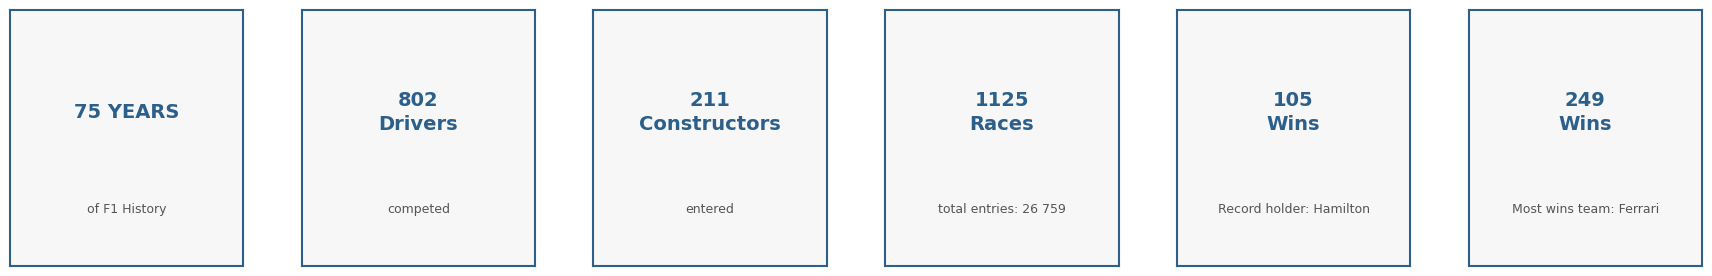

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

wins_df    = df[df["finish_position"] == 1]
top_constr = wins_df["constructor_name"].value_counts().head(10)
top_drivers = wins_df["driver_surname"].value_counts().head(10)
races_per_year = df.drop_duplicates(["year", "raceId"]).groupby("year").size()

kpis = [
    ("75 YEARS",              "of F1 History"),
    ("802\nDrivers",          "competed"),
    ("211\nConstructors",     "entered"),
    (f"{int(races_per_year.sum())}\nRaces", "total entries: 26 759"),
    (f"{top_drivers.iloc[0]}\nWins",        f"Record holder: {list(top_drivers.index)[0]}"),
    (f"{int(top_constr.iloc[0])}\nWins",    f"Most wins team: {top_constr.index[0]}"),
]

fig = plt.figure(figsize=(18, 4), facecolor=BG)
gs  = gridspec.GridSpec(1, 6, figure=fig, wspace=0.25,
                        left=0.03, right=0.97, top=0.82, bottom=0.18)

for i, (val, lbl) in enumerate(kpis):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(PRIMARY)
        sp.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.60, val, ha="center", va="center",
            fontsize=14, fontweight="bold", color=PRIMARY,
            transform=ax.transAxes, linespacing=1.3)
    ax.text(0.5, 0.22, lbl, ha="center", va="center",
            fontsize=9, color=MUTED,
            transform=ax.transAxes)



From 1950 through 2024, the sport has seen 802 drivers and 211 constructors go head to head across more than a thousand race entries. The all-time win tallies need a bit of context to make sense: drivers in the modern era rack up victories over calendars of 20-plus races, while the champions of the 1950s were working with fewer than ten rounds a year. Total wins and win rate are really two different lenses on the same question — what does genuine dominance look like in a given period?

---

## 2. Calendar Growth: Races per Season (1950–2024)

How has the F1 calendar expanded over 75 years? The chart below tracks the number of races per season, annotated by the main technical regulation eras.

Text(0.5, 1.0, 'Number of Races per Season (1950–2024)')

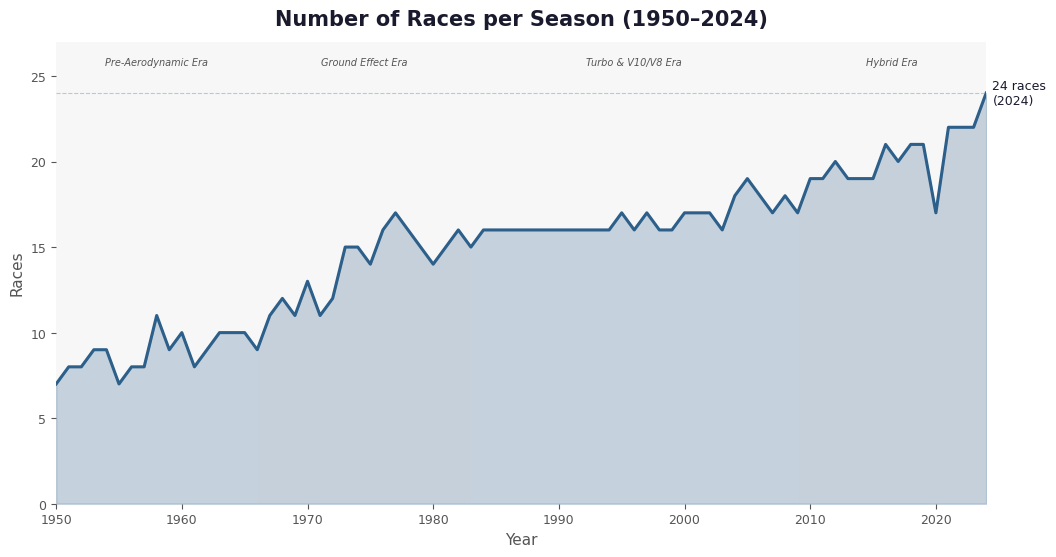

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY   = "#2C5F8A"
SECONDARY = "#7A9BB5"
BG        = "#FFFFFF"
CARD      = "#F7F7F7"
TEXT      = "#1A1A2E"
MUTED     = "#555555"

races_per_year = df.drop_duplicates(["year", "raceId"]).groupby("year").size()
years = races_per_year.index.values
vals  = races_per_year.values

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.tick_params(colors=MUTED, labelsize=9)

ax.fill_between(years, vals, alpha=0.25, color=PRIMARY)
ax.plot(years, vals, color=PRIMARY, linewidth=2.2)
ax.set_xlabel("Year", color=MUTED, fontsize=11)
ax.set_ylabel("Races", color=MUTED, fontsize=11)
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, vals.max() + 3)
ax.axhline(vals.max(), color=SECONDARY, linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(years[-1] + 0.5, vals[-1],
        f"{vals[-1]} races\n({years[-1]})", color=TEXT, fontsize=9, va="center")

era_shades = [
    (1950, 1966, "Pre-Aerodynamic Era"),
    (1966, 1983, "Ground Effect Era"),
    (1983, 2009, "Turbo & V10/V8 Era"),
    (2009, 2024, "Hybrid Era"),
]
era_colors = ["#ffffff08", "#ffffff05", "#ffffff08", "#ffffff05"]
for (y0, y1, lbl), ec in zip(era_shades, era_colors):
    ax.axvspan(y0, y1, color=ec)
    ax.text((y0 + y1) / 2, vals.max() + 1.5, lbl,
            ha="center", va="bottom", fontsize=7, color=MUTED, style="italic")

ax.set_title("Number of Races per Season (1950–2024)",
             color=TEXT, fontsize=15, fontweight="bold", pad=12)

The calendar itself tells its own story. It started at just 7 races in 1950 and hit a record 24 in 2024. The sharpest growth came during the V10 and V8 years roughly 1983 to 2009 as the sport pushed into Asia and the Americas. The hybrid era then brought the fastest expansion yet, fuelled by commercial deals with new venues across the Middle East and Asia Pacific. The growth isn't smooth or linear, though: the jumps tend to cluster around major regulation changes, which typically coincide with rounds of commercial renegotiation, and that's what gives the calendar's expansion its uneven, stop start shape.

---

## 3. Race Outcome Distribution

Out of all 26,759 race entries logged between 1950 and 2024, what actually happened most often when the flag dropped? This donut chart breaks every entry down into six categories based on how each race ended.

Text(0.5, 1.0, 'Race Result Distribution\n(All Entries 1950–2024)')

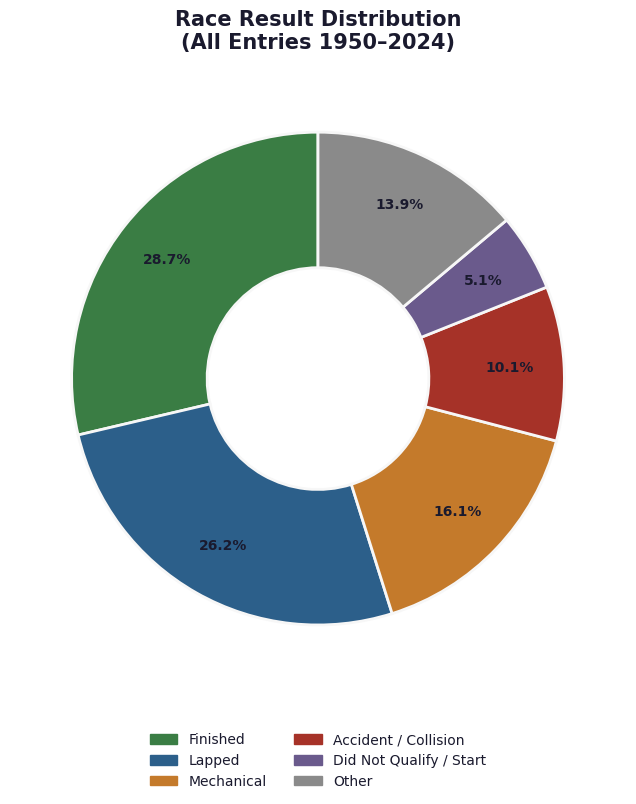

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY  = "#2C5F8A"
BG       = "#FFFFFF"
CARD     = "#F7F7F7"
TEXT     = "#1A1A2E"
MUTED    = "#555555"

fin_map = {
    "Finished":          "Finished",
    "+1 Lap":            "Lapped",
    "+2 Laps":           "Lapped",
    "+3 Laps":           "Lapped",
    "+4 Laps":           "Lapped",
    "+5 Laps":           "Lapped",
    "Engine":            "Mechanical",
    "Gearbox":           "Mechanical",
    "Hydraulics":        "Mechanical",
    "Electrical":        "Mechanical",
    "Suspension":        "Mechanical",
    "Brakes":            "Mechanical",
    "Transmission":      "Mechanical",
    "Accident":          "Accident / Collision",
    "Collision":         "Accident / Collision",
    "Spun off":          "Accident / Collision",
    "Did not qualify":   "Did Not Qualify / Start",
    "Did not prequalify":"Did Not Qualify / Start",
}
df["status_group"] = df["status"].map(fin_map).fillna("Other")
status_counts = df["status_group"].value_counts()

STATUS_COLORS = {
    "Finished":                "#3A7D44",
    "Lapped":                  "#2C5F8A",
    "Mechanical":              "#C47A2B",
    "Accident / Collision":    "#A63228",
    "Did Not Qualify / Start": "#6A5A8C",
    "Other":                   "#8A8A8A",
}

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_aspect("equal")
ax.set_facecolor(BG)

order = ["Finished", "Lapped", "Mechanical", "Accident / Collision",
         "Did Not Qualify / Start", "Other"]
sizes = [status_counts.get(o, 0) for o in order]
colors = [STATUS_COLORS[o] for o in order]

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=CARD, linewidth=2),
)
for at in autotexts:
    at.set_color(TEXT)
    at.set_fontsize(10)
    at.set_fontweight("bold")

patches = [mpatches.Patch(color=STATUS_COLORS[o], label=o) for o in order]
ax.legend(handles=patches, loc="center", frameon=False,
          fontsize=10, labelcolor=TEXT,
          bbox_to_anchor=(0.5, -0.12), ncol=2)

ax.set_title("Race Result Distribution\n(All Entries 1950–2024)",
             color=TEXT, fontsize=15, fontweight="bold", pad=16)

Roughly half of all entries ended in a classified finish. Mechanical failures make up a sizeable chunk of the rest hardly surprising given how fragile early era machinery was though that share dropped noticeably from the 1990s onward as engineering and reliability standards caught up. Accidents and collisions look modest as a raw percentage, but their actual impact on races tends to be far larger than the numbers suggest, since a single incident can trigger a safety car and completely reshape things for everyone on track. The "Did Not Qualify / Start" slice is essentially a pre 1996 artefact: back then, grids regularly exceeded 26 cars, and pre-qualifying was a hurdle drivers had to clear before they even made it to the main event.

---

## 4. Constructor Dominance by Decade

Which teams were actually winning races in each decade, and how did the balance of power shift over time? The stacked bar chart maps out race victories for the top 10 constructors, broken down decade by decade.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_8726/1797522756.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


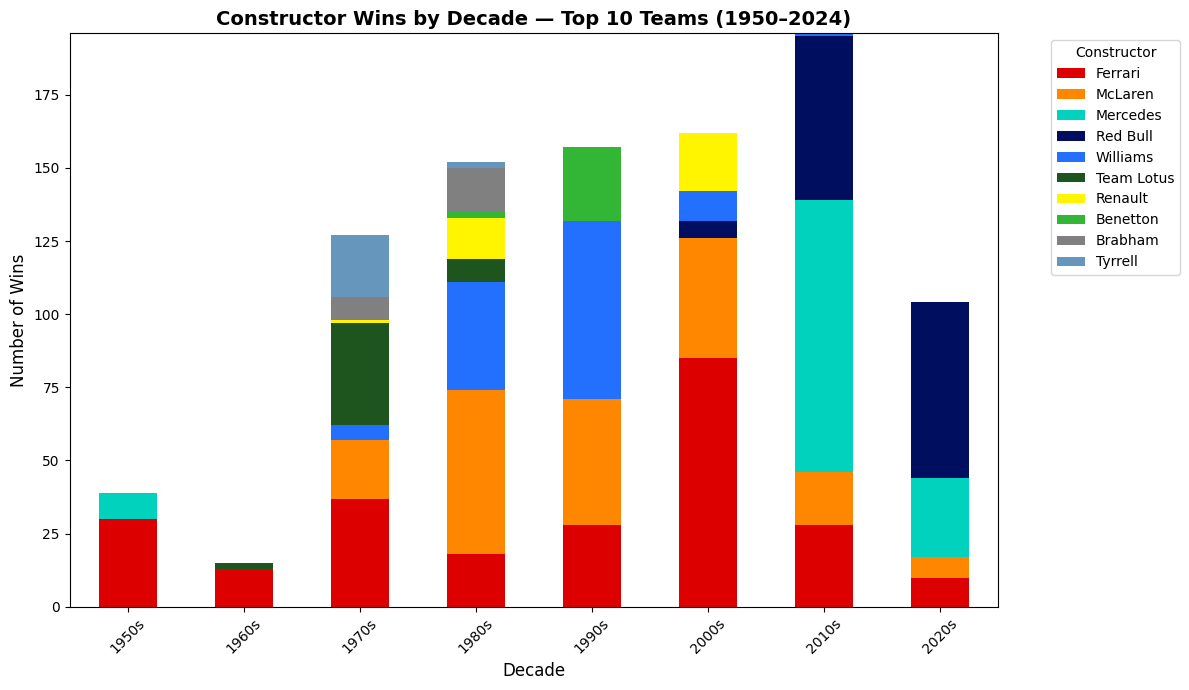

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")

winners = df[df["finish_position"] == 1].copy()
winners["decade"] = (winners["year"] // 10) * 10

wins_by_decade = winners.groupby(["decade", "constructor_name"]).size().unstack(fill_value=0)
top_teams = wins_by_decade.sum().sort_values(ascending=False).head(10).index
wins_by_decade = wins_by_decade[top_teams]
wins_by_decade.index = [f"{d}s" for d in wins_by_decade.index]

TEAM_COLORS = {
    "Ferrari":    "#DC0000",
    "Red Bull":   "#000E5F",
    "Mercedes":   "#00D2BE",
    "Renault":    "#FFF500",
    "Williams":   "#2370FF",
    "McLaren":    "#FF8700",
    "Team Lotus": "#1E551F",
    "Benetton":   "#33B536",
    "Brabham":    "gray",
    "Tyrrell":    "#6696BB",
}

default_colors = plt.cm.tab20.colors
color_list = [
    TEAM_COLORS.get(team, default_colors[i % len(default_colors)])
    for i, team in enumerate(wins_by_decade.columns)
]

wins_by_decade.plot(kind="bar", stacked=True, figsize=(12, 7), color=color_list)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
plt.title("Constructor Wins by Decade — Top 10 Teams (1950–2024)", fontsize=14, fontweight="bold")
plt.legend(title="Constructor", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The thing that jumps out immediately is Ferrari. They're the only constructor to have won races in every single decade from the 1950s through the 2020s a kind of stubborn, continuous presence that no other team comes close to matching. The early years were more of a shared affair, with several British outfits Vanwall, Cooper, BRM all getting their moments before Ferrari started pulling clear. By the 1990s and into the early 2000s, McLaren, Williams, and Ferrari were genuinely trading blows at the front. Then the 2010s became almost entirely Mercedes territory, with seven constructors' championships in a row. The most recent shift belongs to Red Bull, who've taken four consecutive titles from 2021 through 2024 and look, for now at least, like the dominant force of this era.

---

## 5. Fastest Circuits

Which tracks push cars to their absolute speed limits? High average fastest lap speeds are generally a product of long straights, low downforce setups, and not too many slow corners bleeding off momentum.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_8726/834267712.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


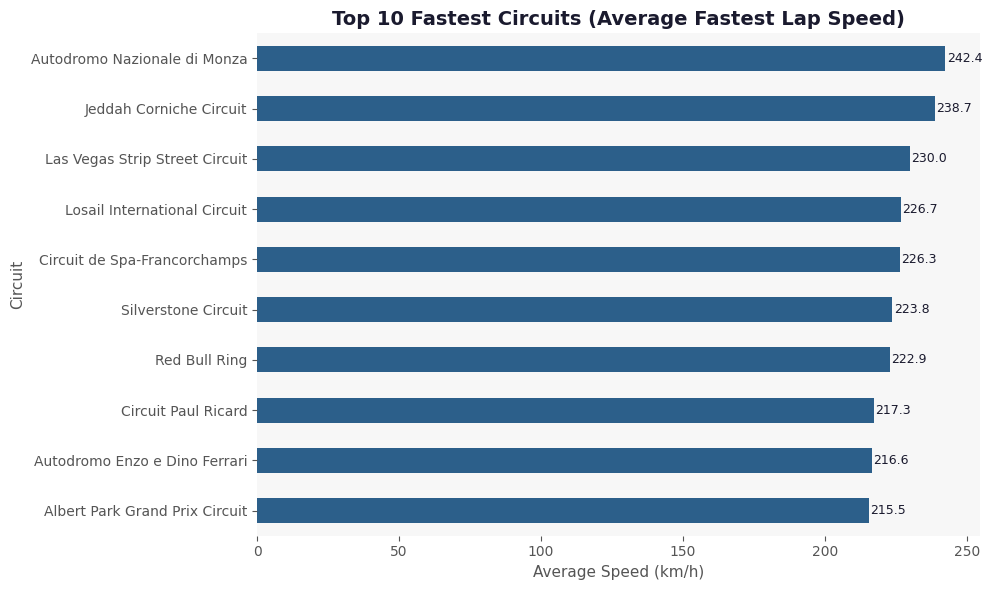

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")
df = df.dropna(subset=["circuit_name", "fastest_lap_speed_kmh"])

fastest_circuits = (
    df.groupby("circuit_name")["fastest_lap_speed_kmh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)

fastest_circuits.sort_values().plot(kind="barh", ax=ax, color=PRIMARY)

ax.set_title("Top 10 Fastest Circuits (Average Fastest Lap Speed)", fontsize=14, fontweight="bold", color=TEXT)
ax.set_xlabel("Average Speed (km/h)", fontsize=11, color=MUTED)
ax.set_ylabel("Circuit", fontsize=11, color=MUTED)
ax.tick_params(colors=MUTED)

for patch in ax.patches:
    ax.text(
        patch.get_width() + 0.5,
        patch.get_y() + patch.get_height() / 2,
        f"{patch.get_width():.1f}",
        va="center", fontsize=9, color=TEXT,
    )

plt.tight_layout()
plt.show()

Monza sits at the top by a clear margin. The Autodromo Nazionale di Monza has consistently clocked average fastest lap speeds above 250 km/h a product of its flat, open layout and four long straights that let cars run flat-out for the majority of the lap. It also demands the lowest-downforce configuration of any race on the calendar, which is part of what makes it so distinctive. Looking at the top 10 fastest circuits as a whole, they're predominantly European venues that were built in the earlier decades of the sport, long before modern circuit design started favouring technical, high-downforce layouts with tighter corners and more varied rhythm sections.

---

## 6. Evolution of Fastest Lap Speeds (2004–2024)

How much have lap speeds actually shifted as the regulations changed? The boxplot maps out the annual spread of fastest lap speeds for the quickest race each year, with each engine era marked up for reference.

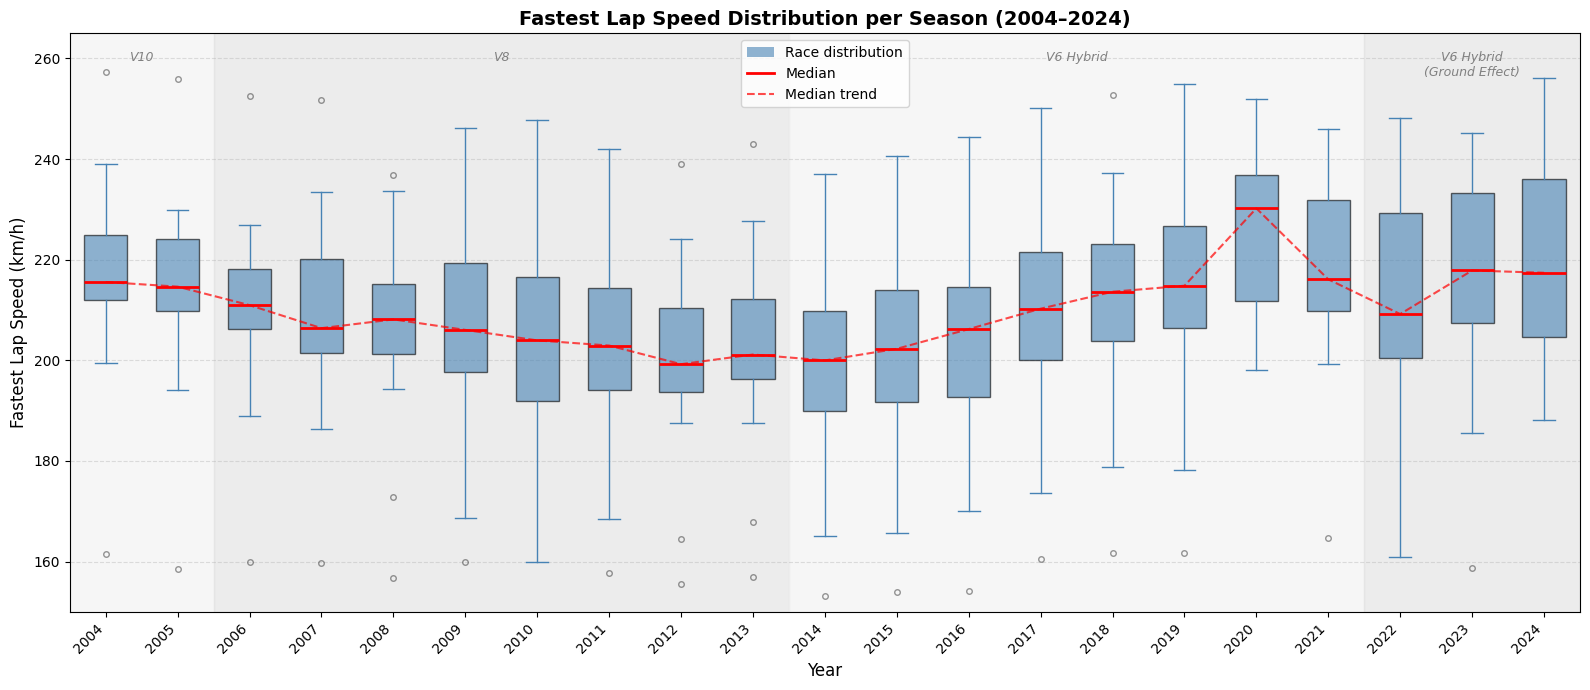

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("mainDataset.csv", low_memory=False)
df = df[df["fastest_lap_rank"] == 1].dropna(subset=["fastest_lap_speed_kmh", "year"])
df["year"] = df["year"].astype(int)

years = sorted(df["year"].unique())
data_by_year = [df[df["year"] == y]["fastest_lap_speed_kmh"].values for y in years]

eras = [
    (2004, 2005, "V10"),
    (2006, 2013, "V8"),
    (2014, 2021, "V6 Hybrid"),
    (2022, 2024, "V6 Hybrid\n(Ground Effect)"),
]
era_colors = ["#f0f0f0", "#e0e0e0", "#f0f0f0", "#e0e0e0"]

fig, ax = plt.subplots(figsize=(16, 7))

for (start, end, label), color in zip(eras, era_colors):
    ax.axvspan(years.index(start) + 0.5, years.index(end) + 1.5,
               color=color, alpha=0.6, zorder=0)
    mid_idx = (years.index(start) + years.index(end)) / 2 + 1
    ax.text(mid_idx, 0.97, label,
            ha="center", va="top", fontsize=9, color="gray", style="italic",
            transform=ax.get_xaxis_transform())

ax.boxplot(data_by_year,
           positions=range(1, len(years) + 1),
           widths=0.6,
           patch_artist=True,
           medianprops=dict(color="red", linewidth=2),
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           whiskerprops=dict(color="steelblue"),
           capprops=dict(color="steelblue"),
           flierprops=dict(marker="o", color="steelblue", alpha=0.4,
                           markersize=4, linestyle="none"))

medians = [np.median(d) for d in data_by_year]
ax.plot(range(1, len(years) + 1), medians,
        color="red", linewidth=1.5, linestyle="--", alpha=0.7)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Fastest Lap Speed (km/h)", fontsize=12)
ax.set_title("Fastest Lap Speed Distribution per Season (2004–2024)", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45, ha="right")
ax.set_ylim(150, 265)
ax.grid(axis="y", linestyle="--", alpha=0.4)

legend_elements = [
    Patch(facecolor="steelblue", alpha=0.6, label="Race distribution"),
    plt.Line2D([0], [0], color="red", linewidth=2, label="Median"),
    plt.Line2D([0], [0], color="red", linewidth=1.5, linestyle="--", alpha=0.7, label="Median trend"),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

The V10 years 2004 and 2005 sit at the top of the chart, with some circuits pushing above 250 km/h. When the switch to 2.4L V8 engines came in 2006, the effect was immediate and measurable: median speeds fell by somewhere in the region of 10 to 15 km/h almost overnight. The V6 Turbo Hybrid formula that arrived in 2014 pulled speeds down again initially, partly due to restrictions on the power units and partly because the cars themselves got heavier. By 2018, though, teams had figured out how to get far more out of the hybrid energy deployment systems, and speeds had largely recovered. Then came the 2022 ground-effect reset, which caused another temporary dip before the cars got back on terms with where they'd been — by 2023 and 2024, competitive speeds were back.

---

## 7. Pit Stop Strategy Evolution

How has the number of pit stops per race changed across the decades? The trend is really a story of regulations reshaping strategy, sometimes dramatically.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_8726/3411801971.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


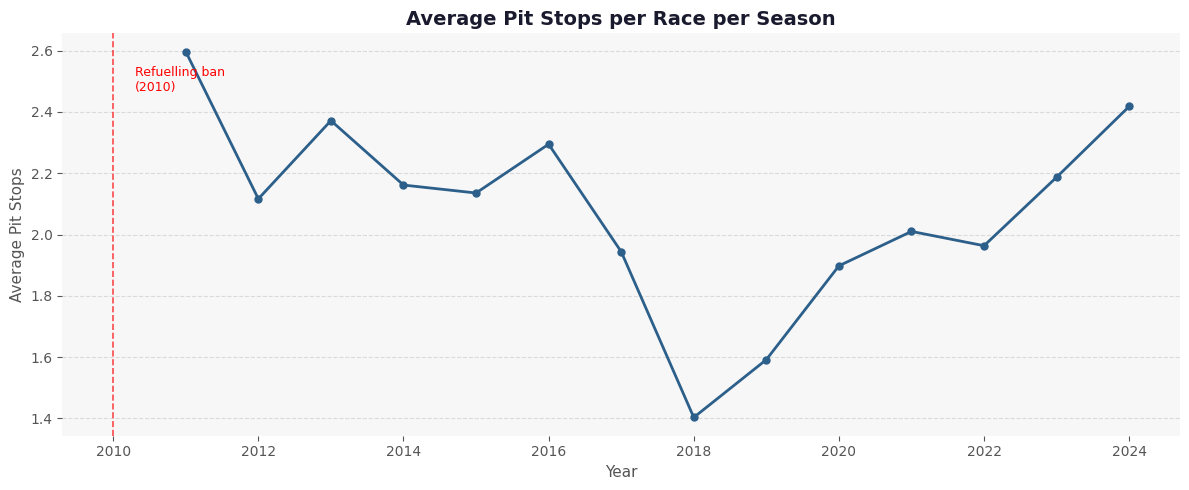

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")
df = df.dropna(subset=["year", "pit_stop_count"])

pitstop_trend = (
    df.groupby("year")["pit_stop_count"]
    .mean()
    .sort_index()
)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)

ax.plot(pitstop_trend.index, pitstop_trend.values,
        marker="o", color=PRIMARY, linewidth=2, markersize=5)
ax.axvline(2010, color="red", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(2010.3, pitstop_trend.max() * 0.95, "Refuelling ban\n(2010)",
        color="red", fontsize=9)

ax.set_title("Average Pit Stops per Race per Season", fontsize=14, fontweight="bold", color=TEXT)
ax.set_xlabel("Year", fontsize=11, color=MUTED)
ax.set_ylabel("Average Pit Stops", fontsize=11, color=MUTED)
ax.tick_params(colors=MUTED)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

The single biggest break in the data comes in 2010, when refuelling during races was banned. Before that, teams were stopping multiple times anyway combining tyre changes with fuel top-ups which naturally pushed average stop counts up. Once refuelling went away, the numbers dropped sharply, and one or two tyre changes became the norm for most races. The mandatory compound rule introduced in 2011, which requires drivers to use at least two different tyre specifications, added a layer of strategic thinking back into the mix without bringing stop counts anywhere close to pre-2010 levels. The gentle upward drift from 2012 onward reflects teams leaning more heavily into two-stop strategies as Pirelli's softer compound ranges started producing noticeably higher tyre degradation.

---

## 8. Grid Position vs. Race Result

Does where you qualify actually tell you where you'll finish? The heatmap plots log scaled frequencies across every qualifying and finishing position combination in the dataset.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_8726/2194640643.py:6: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


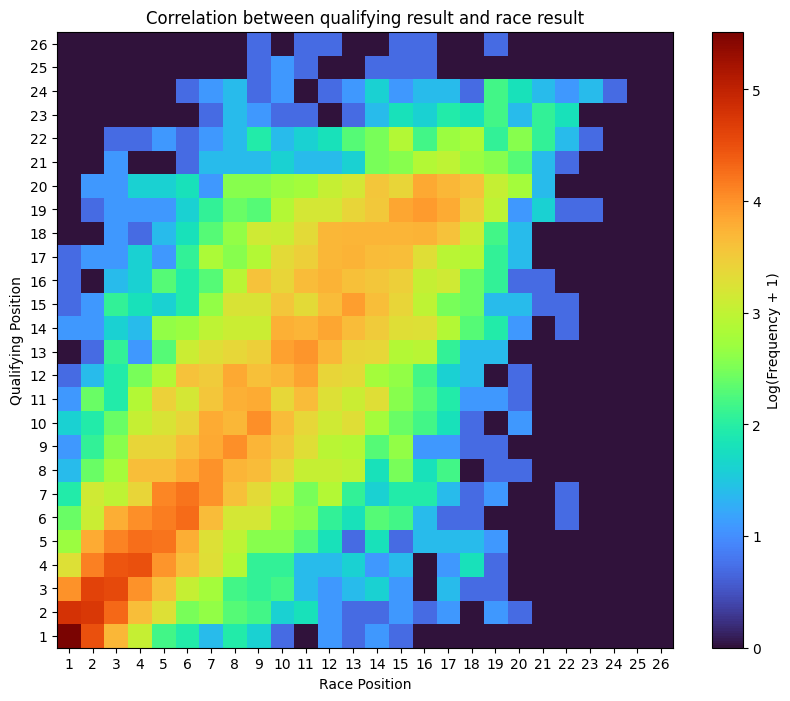

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("mainDataset.csv")

df = df[['quali_position', 'finish_position']].dropna()

df['quali_position'] = pd.to_numeric(df['quali_position'], errors='coerce')
df['finish_position'] = pd.to_numeric(df['finish_position'], errors='coerce')

df = df.dropna()

df = df[(df['quali_position'] >= 1) & (df['quali_position'] <= 30)]
df = df[(df['finish_position'] >= 1) & (df['finish_position'] <= 30)]

heatmap = pd.crosstab(df['quali_position'], df['finish_position'])

heatmap = heatmap.reindex(index=range(1,27), columns=range(1,27), fill_value=0)

data = np.log1p(heatmap)


plt.figure(figsize=(10,8))
plt.imshow(data, cmap='turbo', origin='lower')  


plt.xticks(range(26), range(1,27))
plt.yticks(range(26), range(1,27))

plt.xlabel("Race Position")
plt.ylabel("Qualifying Position")
plt.title("Correlation between qualifying result and race result")

plt.colorbar(label='Log(Frequency + 1)')

plt.show()

The diagonal running through the chart is hard to miss, and it makes the answer fairly clear: qualifying position is the single strongest predictor of where a driver ends up at the flag. Starting from pole gives you the best shot at winning better than any other grid slot. That relationship holds up well through the midfield but starts to loosen toward the back of the grid, where incidents, safety car periods, and opportunistic strategy calls introduce a lot more chaos into outcomes. Just above the main diagonal, there's a secondary concentration that reflects something pretty typical of F1 races: gaining one or two places from your starting position is common, and the heatmap captures that pattern clearly. The clusters that appear well away from the diagonal are where things got interesting safety car restarts that reshuffled the order, strategic gambles that paid off or didn't, or front-runners retiring and handing positions down the field.

---

## 9. Geographic Distribution of F1 Races (1950–2024)

How far has Formula 1 actually spread across the globe over 75 years? The left panel ranks the top 20 host countries by total races held; the right tracks the five most active countries per decade to show how the sport's geographic footprint shifted.

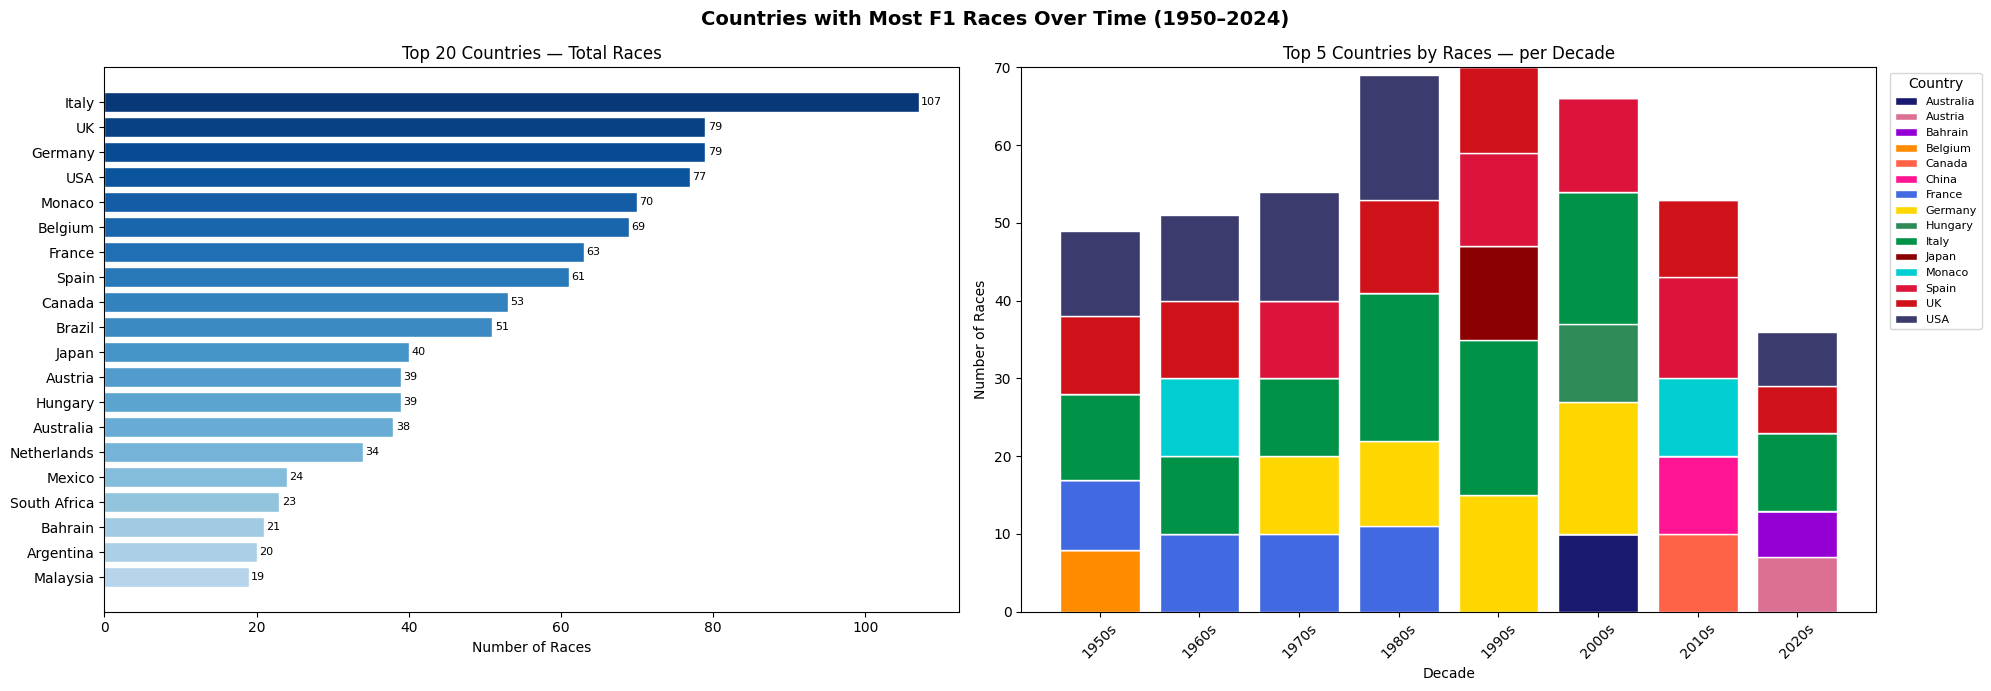

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
unique_races = df.drop_duplicates(subset="raceId")[["raceId", "country", "year"]]

races_per_country = (
    unique_races.groupby("country").size()
    .reset_index(name="n_races")
    .sort_values("n_races", ascending=False)
)

unique_races["decade"] = (unique_races["year"] // 10 * 10).astype(str) + "s"

races_per_decade = (
    unique_races.groupby(["country", "decade"]).size()
    .reset_index(name="n_races")
)

top5_per_decade = (
    races_per_decade.sort_values("n_races", ascending=False)
    .groupby("decade")
    .head(5)
)

pivot = (
    top5_per_decade.pivot(index="decade", columns="country", values="n_races")
    .fillna(0)
)

FLAG_COLORS = {
    "Italy":        "#009246",
    "Germany":      "#FFD700",
    "UK":           "#CF111A",
    "USA":          "#3C3B6E",
    "Monaco":       "#00CED1",
    "Belgium":      "#FF8C00",
    "France":       "#4169E1",
    "Spain":        "#DC143C",
    "Canada":       "#FF6347",
    "Brazil":       "#228B22",
    "Japan":        "#8B0000",
    "Austria":      "#DB7093",
    "Hungary":      "#2E8B57",
    "Australia":    "#191970",
    "Netherlands":  "#FF4500",
    "Mexico":       "#556B2F",
    "South Africa": "#DAA520",
    "Bahrain":      "#9400D3",
    "Argentina":    "#87CEEB",
    "Malaysia":     "#8B4513",
    "Switzerland":  "#A9A9A9",
    "Sweden":       "#4682B4",
    "Portugal":     "#006400",
    "China":        "#FF1493",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Countries with Most F1 Races Over Time (1950–2024)", fontsize=14, fontweight="bold")

top20 = races_per_country.head(20)
blues = plt.cm.Blues([0.3 + 0.7 * i / len(top20) for i in range(len(top20))])
bars = axes[0].barh(top20["country"][::-1], top20["n_races"][::-1], color=blues, edgecolor="white")
axes[0].set_title("Top 20 Countries — Total Races")
axes[0].set_xlabel("Number of Races")
for bar, val in zip(bars, top20["n_races"][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)

decades = sorted(pivot.index.tolist())
bottom = np.zeros(len(decades))
x = np.arange(len(decades))

for country in pivot.columns:
    values = [pivot.loc[d, country] if d in pivot.index else 0 for d in decades]
    if sum(values) == 0:
        continue
    color = FLAG_COLORS.get(country, "#AAAAAA")
    axes[1].bar(x, values, bottom=bottom, label=country, color=color, edgecolor="white")
    bottom += np.array(values)

axes[1].set_title("Top 5 Countries by Races — per Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Races")
axes[1].set_xticks(x)
axes[1].set_xticklabels(decades, rotation=45)
axes[1].legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

The United Kingdom sits at the top of the all-time list, which isn't a huge surprise Silverstone has been on the calendar since the very beginning in 1950, and Britain has long been the engineering heartland of the sport. Italy and Germany follow, both with deep roots in the championship's history. The decade-by-decade view is where things get more interesting. Through the 1950s, 60s, 70s, and into the 80s, Formula 1 was essentially a European affair. From the 1990s onward, that started to change — North America, Asia, and the Middle East all began claiming their share of the calendar. Since 2010, venues like Bahrain, Abu Dhabi, Singapore, Japan, and China have become regulars, which reflects a broader commercial shift: the sport's growth strategy has increasingly pointed toward high-revenue markets well outside its traditional European base.

---

## 10. Pit Stop Count by Start and Finish Position

Does the number of pit stops you make have anything to do with where you start and finish? The heatmap looks at average stop counts for each start/finish position combination, limited to the post-refuelling-ban era where pit strategy actually means something on its own terms.

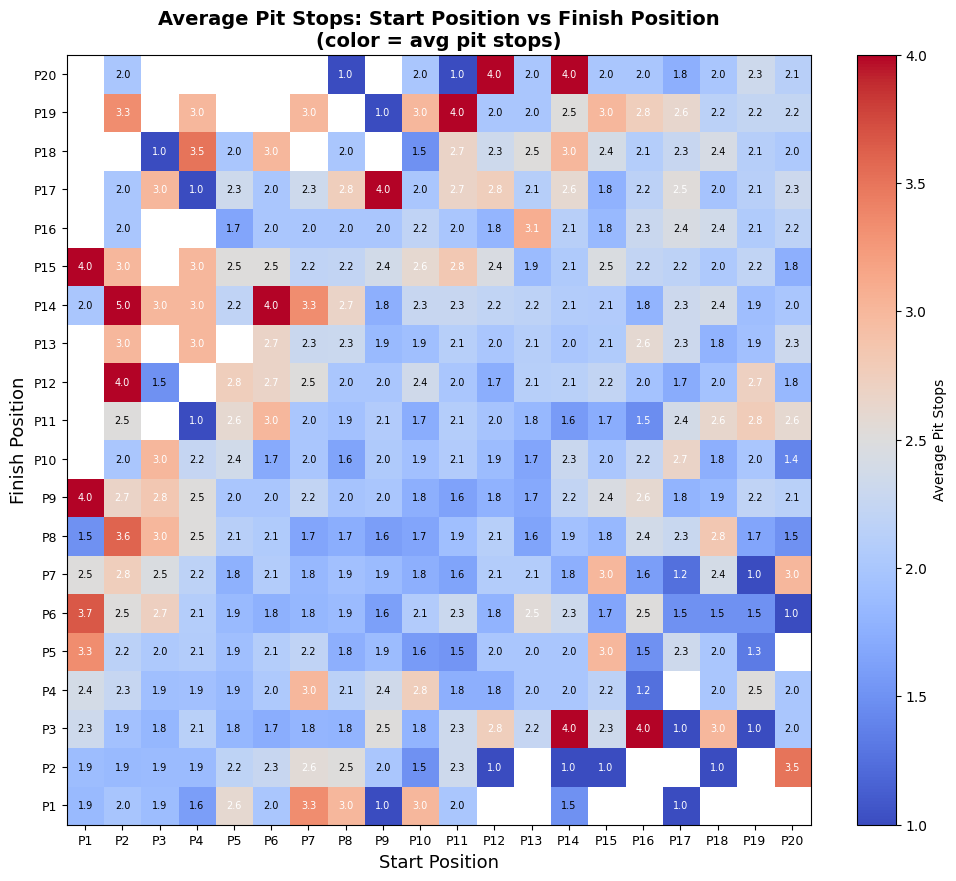

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
df_pit = df[["start_position", "finish_position", "pit_stop_count"]].dropna()

df_pit = df_pit[
    (df_pit["start_position"].between(1, 20)) &
    (df_pit["finish_position"].between(1, 20)) &
    (df_pit["pit_stop_count"].between(1, 6))
]
df_pit["start_position"] = df_pit["start_position"].astype(int)
df_pit["finish_position"] = df_pit["finish_position"].astype(int)

heatmap_data = (
    df_pit.groupby(["finish_position", "start_position"])["pit_stop_count"]
    .mean()
    .unstack(fill_value=np.nan)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(heatmap_data.values, cmap="coolwarm", aspect="auto",
               vmin=1, vmax=4)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f"P{int(c)}" for c in heatmap_data.columns], fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f"P{int(i)}" for i in heatmap_data.index], fontsize=9)

ax.set_xlabel("Start Position", fontsize=13)
ax.set_ylabel("Finish Position", fontsize=13)
ax.set_title("Average Pit Stops: Start Position vs Finish Position\n(color = avg pit stops)", fontsize=14, fontweight="bold")

ax.invert_yaxis()

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            color = "white" if (val > 2.5 or val < 1.5) else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=color)

cbar = plt.colorbar(im, ax=ax, label="Average Pit Stops")
cbar.set_ticks([1, 1.5, 2, 2.5, 3, 3.5, 4])

plt.show()

The pattern at the front is fairly intuitive: drivers who start near the top and stay there tend to make fewer stops. That's largely because leading cars can dictate their own strategy they can time the undercut or overcut on their own terms without having to worry about fighting through traffic after a pit visit. Further down the grid, average stop counts climb, which lines up with the more aggressive, multi stop approaches that midfield teams typically reach for when they're trying to manufacture positions they can't take on raw pace. What the heatmap doesn't really show, though, is any consistent link between a high number of stops and dramatic position gains. The numbers suggest that outright speed tends to win the argument over strategy: no particular combination of starting slot and stop count reliably turns a fifteenth place grid position into a top five finish when you look at the aggregate picture.

---

## 11. Driver Win Rate (minimum 50 race starts)

Which drivers actually won the most often, relative to how many times they showed up on the grid? Win rate cuts through differences in career length and calendar size, measuring dominance against participation rather than just stacking up totals.

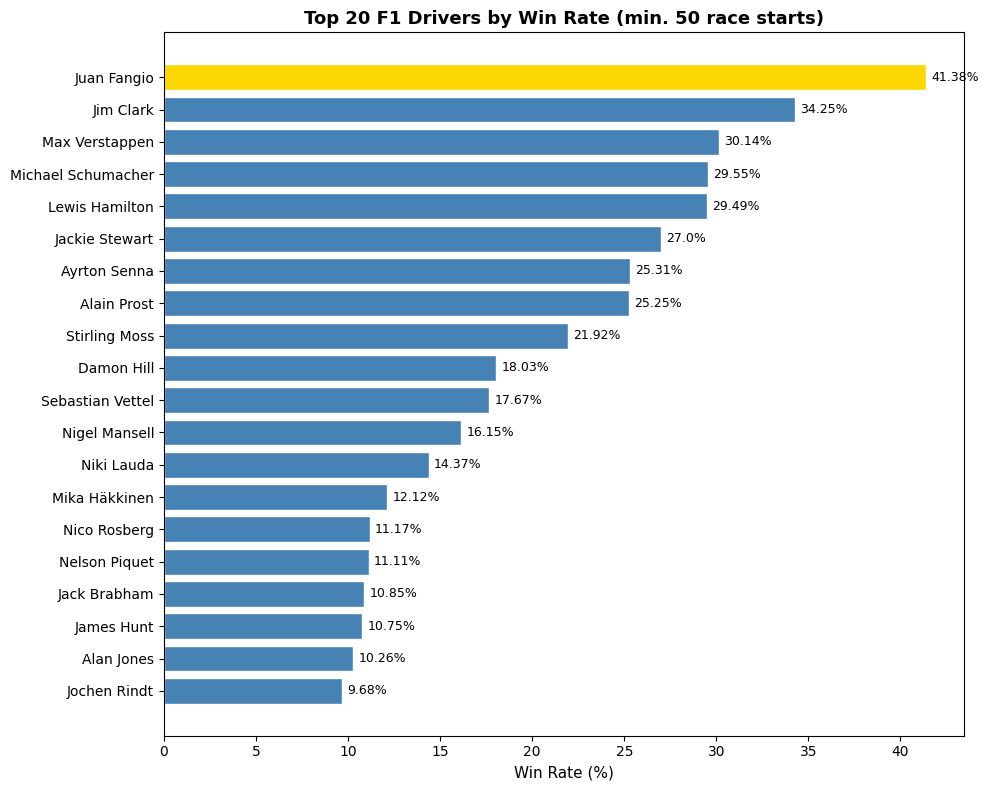

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv", low_memory=False)

win_rate = (
    df.groupby(["driver_forename", "driver_surname"])
    .agg(
        races_entered=("raceId", "count"),
        wins=("finish_position", lambda x: (x == 1.0).sum()),
    )
    .reset_index()
)

win_rate["win_rate_%"] = (win_rate["wins"] / win_rate["races_entered"] * 100).round(2)
win_rate["driver"] = win_rate["driver_forename"] + " " + win_rate["driver_surname"]
win_rate = win_rate[win_rate["races_entered"] >= 50].sort_values("win_rate_%", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(win_rate))]
ax.barh(win_rate["driver"][::-1], win_rate["win_rate_%"][::-1], color=colors[::-1], edgecolor="white")
ax.set_title("Top 20 F1 Drivers by Win Rate (min. 50 race starts)", fontsize=13, fontweight="bold")
ax.set_xlabel("Win Rate (%)", fontsize=11)
for i, val in enumerate(win_rate["win_rate_%"][::-1]):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("win_rate_piloti.png", dpi=150)
plt.show()

Juan Manuel Fangio sits at the top with a win rate north of 41%, spread across just 51 starts during the 1950s a number that no driver in any later era has come anywhere close to. Hamilton, Vettel, and Verstappen all rank considerably lower in percentage terms despite their enormous win tallies in absolute numbers, and that's simply because they're racing over 20plus round seasons against twenty other cars that are all genuinely capable of winning on any given weekend. The gap between Fangio and everyone else is a good reminder of why the metric you choose matters so much: win rate captures how completely a driver dominated their own era, while total wins reflect something different the ability to sustain excellence over a long stretch of time. Honestly, neither number on its own gives you the full picture of who the greatest drivers in the sport's history actually were.

---

## Conclusions

Seventy-five years of Formula 1 data, when you sit down and actually look at all of it together, tells a pretty consistent story. The calendar went from 7 races in 1950 to 24 in 2024 pulled along by commercial deals that dragged the sport into Asia, the Americas, and the Middle East, which the geographic charts show pretty plainly. And yet, for all that growth and all those new venues, the actual winning has stayed in remarkably few hands. Ferrari, McLaren, Williams, Mercedes, Red Bull the same small club, decade after decade, sharing out the bulk of the victories between them. And whenever the balance shifts from one to another, there's almost always a regulation change sitting right behind it. It rarely just happens on its own.

That's really where the data speaks loudest at the regulation boundaries. The jump from V10s to V8s in 2006, the refuelling ban in 2010, the hybrid switch in 2014, the ground effect reset in 2022 every single one of those moments left a mark you can actually see, in lap speeds, in pit stop counts, in how the numbers just suddenly change. You don't need to go looking for it. The breaks are right there. The qualifying to finish heatmap backs up something any F1 fan already feels in their gut: starting at the front is still the single biggest advantage you can have. That holds up pretty well through the midfield, then starts falling apart toward the back of the grid, where a safety car or a bold strategy call can flip things around completely.

When you step back from all of it, what the data is really drawing is a portrait of a sport where the competitive eras are written by the rulebook, the calendar follows the money, and you can't really judge what any driver achieved without first understanding exactly when they did it.